# Thermal Profile

Analysis of core battery temperature change over time with and without external styrofoam insulation.

In [6]:
import os
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd

import darkdetect

plt.rcdefaults()

if darkdetect.isDark():
    plt.style.use("dark_background")

plt.rcParams.update(
    {
        "figure.dpi": 300,
        "figure.figsize": (8, 6),
    }
)

%config InlineBackend.figure_formats = ["svg"]
# %config InlineBackend.figure_format = 'retina'

In [7]:
THERMAL_DATA_CSV = "../Data/Calorimetry/HR12-9 Calorimetry.csv"

therm_df = pd.read_csv(THERMAL_DATA_CSV, sep="	")
# Format Date/Time as duration
therm_df["Date/Time"] = pd.to_datetime(therm_df["Time"], format="%H:%M:%S")

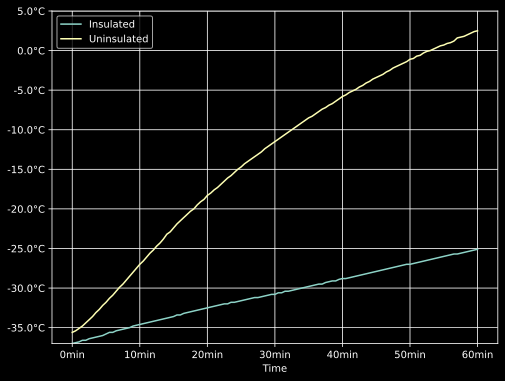

In [8]:
from matplotlib.ticker import FuncFormatter
from matplotlib.figure import Figure


def plotThermalProfile(therm_df, **kwargs) -> Figure:
    ax = therm_df.plot(
        x="Time",
        y=["Temp (Insulated) (°C)", "Temp (Uninsulated) (°C)"],
        ylim=(therm_df["Temp (Insulated) (°C)"].min(), 5),
        # marker="+",
        grid=True,
        **kwargs,
    )
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}°C"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x/2)}min"))
    ax.legend(["Insulated", "Uninsulated"])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x}°C"))

    return ax.get_figure()


_ = plotThermalProfile(
    therm_df,
)
_

## Tikz Plots

In [9]:
from cycler import cycler

colorBlindColours = [
    "#377eb8",
    "#ff7f00",
    "#4daf4a",
    "#f781bf",
    "#a65628",
    "#984ea3",
    "#999999",
    "#e41a1c",
    "#dede00",
    "#000000",
]

matplotlib.use("pgf")

plt.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "axes.prop_cycle": cycler(
            linestyle=["-", "--"],
            # color=colorBlindColours,
        ),
    }
)

TIKZ_SAVE_PATH = os.path.join("../Plots/Latex")
os.makedirs(TIKZ_SAVE_PATH, exist_ok=True)

In [10]:
thermalProfileFig = plotThermalProfile(
    therm_df,
    color=[
        "#444444",
        "#444444",
        # "#bbbbbb",
    ],
)

thermalProfileFig.savefig(
    os.path.join(TIKZ_SAVE_PATH, "thermal_profile.pgf"),
    bbox_inches="tight",
    pad_inches=0.1,
)